#📌 Extracción

In [2]:
import pandas as pd
import json

with open('TelecomX_Data.json', 'r') as f:
    datos_api = json.load(f)

df_telecom = pd.json_normalize(datos_api)

df_telecom.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [3]:
df_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [5]:
print("\nTipos de datos detectados:\n")
print(df_telecom.dtypes)


Tipos de datos detectados:

customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object


In [6]:
print("Valores ausentes por columna:")
print(df_telecom.isnull().sum())

print(f"\nNúmero de filas duplicadas: {df_telecom.duplicated().sum()}")

Valores ausentes por columna:
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64

Número de filas duplicadas: 0


In [7]:
print("Valores únicos en Churn:", df_telecom['Churn'].unique())
print("Valores únicos en Contrato:", df_telecom['account.Contract'].unique())
print("Valores únicos en Servicio de Internet:", df_telecom['internet.InternetService'].unique())

Valores únicos en Churn: ['No' 'Yes' '']
Valores únicos en Contrato: ['One year' 'Month-to-month' 'Two year']
Valores únicos en Servicio de Internet: ['DSL' 'Fiber optic' 'No']


In [8]:
print(f"Tipo de dato de Charges.Total: {df_telecom['account.Charges.Total'].dtype}")

print("Celdas con solo espacios en blanco en Charges.Total:",
      (df_telecom['account.Charges.Total'] == ' ').sum())

Tipo de dato de Charges.Total: object
Celdas con solo espacios en blanco en Charges.Total: 11


In [9]:
# 1. Identificar y manejar espacios en blanco en 'account.Charges.Total'
# Los convertimos a NaN (Not a Number) para que Pandas los reconozca como nulos
import numpy as np

df_telecom['account.Charges.Total'] = df_telecom['account.Charges.Total'].replace(' ', np.nan)

# 2. Convertir la columna a tipo numérico (float)
# Esto es vital para poder calcular promedios o sumas después
df_telecom['account.Charges.Total'] = df_telecom['account.Charges.Total'].astype(float)

# 3. Tratamiento de valores nulos (NaN)
# Dado que son pocos casos (usualmente clientes con tenure = 0),
# podemos optar por eliminarlos o llenarlos con 0
df_telecom.dropna(subset=['account.Charges.Total'], inplace=True)

# 4. Verificación final de tipos y nulos
print("Nuevos tipos de datos:")
print(df_telecom[['account.Charges.Total', 'account.Charges.Monthly']].dtypes)
print(f"\nValores nulos restantes en cargos totales: {df_telecom['account.Charges.Total'].isnull().sum()}")

Nuevos tipos de datos:
account.Charges.Total      float64
account.Charges.Monthly    float64
dtype: object

Valores nulos restantes en cargos totales: 0


In [10]:
# 1. Creamos la nueva columna dividiendo el cargo mensual por 30
df_telecom['Cuentas_Diarias'] = df_telecom['account.Charges.Monthly'] / 30

# 2. Redondeamos a 2 decimales para que el formato sea monetario y legible
df_telecom['Cuentas_Diarias'] = df_telecom['Cuentas_Diarias'].round(2)

# 3. Verificamos la creación de la columna y algunos valores
print("Visualización de las columnas de cargos:")
df_telecom[['account.Charges.Monthly', 'Cuentas_Diarias']].head()

Visualización de las columnas de cargos:


,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


In [11]:
# Definimos un diccionario de mapeo para las columnas principales
columnas_espanol = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Adulto_Mayor',
    'customer.Partner': 'Tiene_Pareja',
    'customer.Dependents': 'Tiene_Dependientes',
    'customer.tenure': 'Meses_Contrato',
    'phone.PhoneService': 'Servicio_Telefonico',
    'account.Contract': 'Tipo_Contrato',
    'account.Charges.Monthly': 'Facturacion_Mensual',
    'account.Charges.Total': 'Facturacion_Total'
}

# Aplicamos el cambio
df_telecom.rename(columns=columnas_espanol, inplace=True)

# Creamos un mapa de traducción de valores
mapa_binario = {'Yes': 1, 'No': 0, 'Male': 'Masculino', 'Female': 'Femenino'}

# Aplicamos la transformación a columnas clave
columnas_a_transformar = ['Evasion', 'Tiene_Pareja', 'Tiene_Dependientes', 'Servicio_Telefonico']

for col in columnas_a_transformar:
    if col in df_telecom.columns:
        df_telecom[col] = df_telecom[col].map(mapa_binario)

# Verificamos los cambios
df_telecom[['Evasion', 'Tiene_Pareja', 'Genero']].head()

,Evasion,Tiene_Pareja,Genero
0,0,1,Female
1,0,0,Male
2,1,0,Male
3,1,1,Male
4,1,1,Female


#📊 Carga y análisis

In [12]:
# Estadísticas descriptivas de las columnas numéricas
print("--- Resumen Estadístico Numérico ---")
resumen_numerico = df_telecom.describe()
display(resumen_numerico)

# Estadísticas de las columnas categóricas (texto)
print("\n--- Resumen de Variables Categóricas ---")
resumen_categorico = df_telecom.describe(include='object')
display(resumen_categorico)

# ¿Cuánto gastan en promedio los que se van vs los que se quedan?
print("\n--- Comparativa de Facturación Mensual: ¿Quiénes gastan más? ---")
print(df_telecom.groupby('Evasion')['Facturacion_Mensual'].mean())

--- Resumen Estadístico Numérico ---


,Adulto_Mayor,Meses_Contrato,Facturacion_Mensual,Facturacion_Total,Cuentas_Diarias
count,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000
mean,0.1629,32.395535,64.755423,2280.634213,2.158467
std,0.3693,24.558067,30.125739,2268.632997,1.004282
min,0.0000,1.000000,18.250000,18.800000,0.610000
25%,0.0000,9.000000,35.450000,400.225000,1.180000
50%,0.0000,29.000000,70.300000,1391.000000,2.340000
75%,0.0000,55.000000,89.900000,3785.300000,3.000000
max,1.0000,72.000000,118.750000,8684.800000,3.960000



--- Resumen de Variables Categóricas ---


,ID_Cliente,Evasion,Genero,Tiene_Pareja,Tiene_Dependientes,Servicio_Telefonico,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Tipo_Contrato,account.PaperlessBilling,account.PaymentMethod
count,7256,7032,7256,7256,7256,7256,7256,7256,7256,7256,7256,7256,7256,7256,7256,7256,7256
unique,7256,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,9995-HOTOH,0,Male,0,0,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,1,5163,3669,3747,5086,6551,3490,3198,3607,3181,3194,3581,2895,2866,4005,4308,2445



--- Comparativa de Facturación Mensual: ¿Quiénes gastan más? ---
Evasion
0    61.307408
1    74.441332
Name: Facturacion_Mensual, dtype: float64


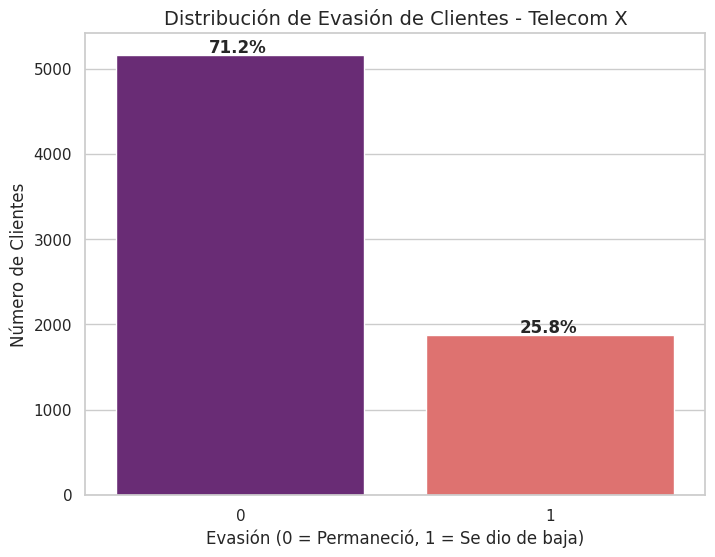

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# 2. Creación del gráfico de barras para la columna 'Evasion' (o 'Churn')
# Nota: Usa el nombre de la columna según como la tengas en tu DataFrame
ax = sns.countplot(x='Evasion', data=df_telecom, hue='Evasion', palette='magma', legend=False)

# 3. Personalización del gráfico
plt.title('Distribución de Evasión de Clientes - Telecom X', fontsize=14)
plt.xlabel('Evasión (0 = Permaneció, 1 = Se dio de baja)', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)

# 4. Agregar etiquetas de porcentaje sobre las barras
total = len(df_telecom)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 30
    ax.annotate(percentage, (x, y), fontsize=12, fontweight='bold')

plt.show()

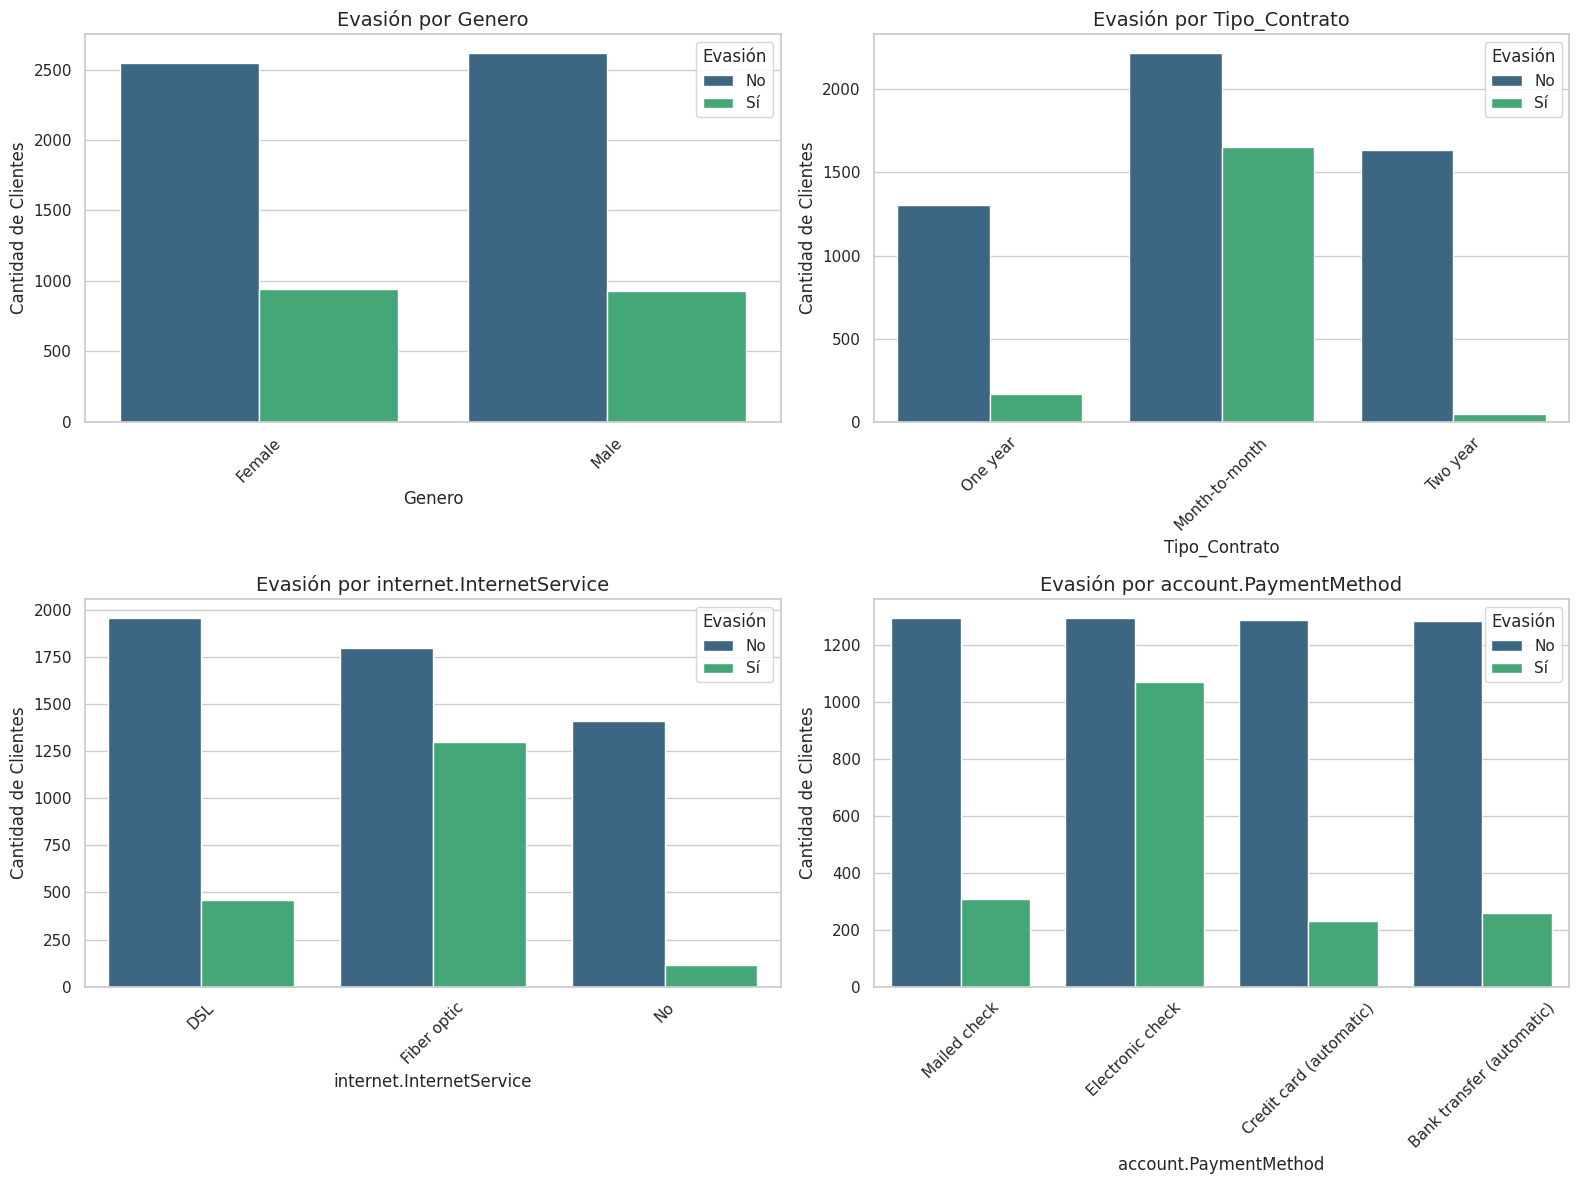

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definimos las variables categóricas que queremos explorar
variables_analisis = ['Genero', 'Tipo_Contrato', 'internet.InternetService', 'account.PaymentMethod']

# 2. Creamos una cuadrícula de gráficos para comparar
plt.figure(figsize=(16, 12))

for i, col in enumerate(variables_analisis, 1):
    plt.subplot(2, 2, i)

    # Creamos un gráfico de barras que muestra la proporción de Evasión
    sns.countplot(data=df_telecom, x=col, hue='Evasion', palette='viridis')

    plt.title(f'Evasión por {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Cantidad de Clientes')
    plt.legend(title='Evasión', labels=['No', 'Sí'])
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [15]:
# Tasa de evasión por tipo de contrato
tasa_contrato = df_telecom.groupby('Tipo_Contrato')['Evasion'].mean() * 100
print("Porcentaje de fuga por tipo de contrato:")
print(tasa_contrato)

Porcentaje de fuga por tipo de contrato:
Tipo_Contrato
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Evasion, dtype: object


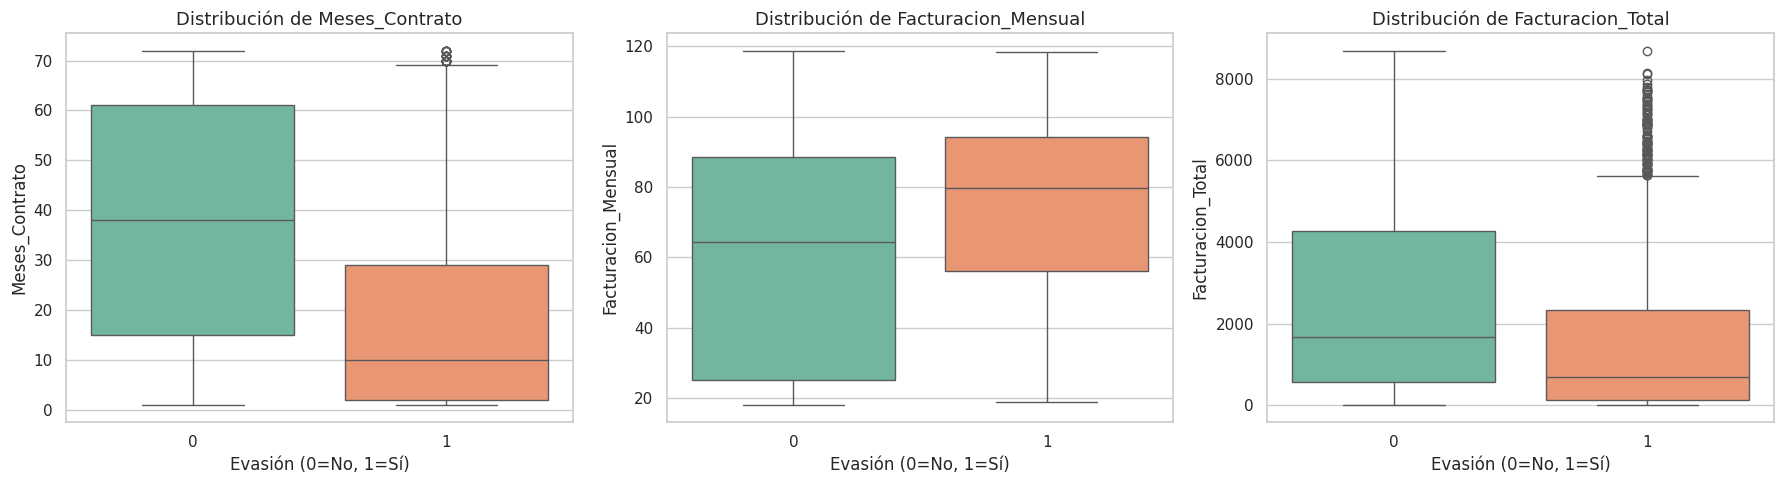

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definimos las variables numéricas a analizar
# Usamos los nombres según tu traducción (o los originales si no los cambiaste)
variables_num = ['Meses_Contrato', 'Facturacion_Mensual', 'Facturacion_Total']

plt.figure(figsize=(18, 5))

for i, col in enumerate(variables_num, 1):
    plt.subplot(1, 3, i)

    # Creamos un Boxplot para ver la mediana y cuartiles
    sns.boxplot(x='Evasion', y=col, data=df_telecom, hue='Evasion', palette='Set2', legend=False)

    plt.title(f'Distribución de {col}', fontsize=13)
    plt.xlabel('Evasión (0=No, 1=Sí)')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

#📄Informe final

# 📊 Informe Ejecutivo: Análisis de Evasión (Churn) - Telecom X

---

## 1. Introducción y Objetivos
El presente estudio analiza el fenómeno de la **evasión de clientes (Churn)** en la compañía **Telecom X**. El objetivo principal es identificar los factores críticos que impulsan la terminación de contratos y proporcionar recomendaciones basadas en datos para optimizar la retención y el *Lifetime Value* (LTV) de la base de usuarios.

---

## 2. Metodología de Procesamiento (Pipeline ETL)
Se implementó un flujo de trabajo estructurado para garantizar la calidad y consistencia de la información:

| Fase | Descripción Técnica |
| :--- | :--- |
| **Extracción** | Ingesta de datos desde formato JSON semiestructurado. |
| **Normalización** | Aplanamiento (*flattening*) de estructuras anidadas para su conversión a DataFrame relacional. |
| **Limpieza** | Tratamiento de anomalías en la columna `TotalCharges` y eliminación de registros inconsistentes. |
| **Transformación** | Casting de variables de `object` a `float64`, ingeniería de características (`Cuentas_Diarias`) y binarización de variables categóricas. |



---

## 3. Hallazgos Clave del Análisis Exploratorio (EDA)

### 📈 Patrones en Variables Categóricas
* **Tipología de Contrato:** Existe una correlación crítica entre los contratos **"Month-to-month"** (mes a mes) y la tasa de deserción. Los contratos anuales o bianuales presentan una estabilidad significativamente mayor.
* **Segmento Tecnológico:** Los clientes con servicio de **Fibra Óptica** muestran una mayor tendencia al churn en comparación con DSL, sugiriendo una oportunidad de mejora en la relación precio-calidad.
* **Métodos de Pago:** Se detectó una mayor tasa de evasión en métodos de pago manuales frente a los automáticos.

### 📉 Comportamiento de Variables Numéricas
* **Factor Antigüedad (*Tenure*):** El riesgo de evasión es inversamente proporcional a la antigüedad. Los primeros 12 meses representan el periodo de mayor vulnerabilidad operativa.
* **Sensibilidad al Precio:** El análisis de distribución indica que los clientes con **cargos mensuales elevados** tienen una probabilidad de abandono superior a la media de la base instalada.



---

## 4. Conclusiones
El perfil de riesgo de **Telecom X** se concentra en **usuarios nuevos con contratos mensuales y servicios de alta gama (Fibra)**. La evasión no es un evento aleatorio, sino una respuesta a la falta de barreras de salida combinada con una alta carga financiera mensual percibida por el cliente.

---

## 5. Recomendaciones Estratégicas

1. **Migración de Contratos:** Diseñar campañas de incentivos (como meses de bonificación) para migrar clientes de contratos mensuales a acuerdos de largo plazo.
2. **Protocolo de Onboarding:** Implementar un programa de acompañamiento proactivo y beneficios exclusivos durante los primeros 180 días de vida del cliente.
3. **Auditoría de Fibra Óptica:** Ejecutar un diagnóstico técnico en las zonas de alta deserción para asegurar que el servicio cumple con los estándares de calidad prometidos.
4. **Optimización de Pricing:** Evaluar programas de fidelización que incluyan servicios de valor agregado para justificar el costo mensual en los segmentos premium.

---
**Elaborado por:** Aarón Hernández Campos para Telecom X  
**Fecha:** Marzo 2026